In [203]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [204]:
SYMBOL = '1000PEPE'
INTERVAL = '1h'
RUN_NAME = '3rd_baseline_pricevssma_vol_spike'

N_ESTIMATORS = 500
MAX_DEPTH = 10
SEED = 42

In [205]:
db_path = '../database/financial_data.duckdb'
conn = duckdb.connect(db_path, read_only=True)

query = f"select * from gold_ml_features where asset_symbol = '{SYMBOL}' and interval = '{INTERVAL}'"
df = conn.execute(query).df()
print(f"total rows loaded: {len(df)}")

total rows loaded: 25564


In [206]:
mlflow.set_tracking_uri("http://localhost:5000")

In [207]:
asset = df['asset_symbol'].iloc[0]
interval = df['interval'].iloc[0]
print(f" {asset} ({interval})")

 1000PEPE (1h)


In [208]:
low = df['log_returns'].quantile(0.01)
high = df['log_returns'].quantile(0.99)
df['log_returns_cleaned'] = df['log_returns'].clip(lower=low, upper=high)

In [209]:
print(df.columns)

Index(['asset_symbol', 'asset_class', 'exchange', 'interval', 'date', 'open',
       'high', 'low', 'close', 'volume', 'daily_volatility', 'sma_7', 'sma_30',
       'rsi_14', 'macd', 'macd_signal', 'macd_histogram', 'roc_10', 'roc_20',
       'stoch_k', 'stoch_d', 'ema_12', 'ema_26', 'ema_50', 'ema_200', 'sma_50',
       'sma_100', 'sma_200', 'bb_upper', 'bb_middle', 'bb_lower', 'bb_width',
       'bb_percentage', 'atr_14', 'obv', 'vwap', 'volume_sma_20',
       'volume_ratio', 'returns_1d', 'returns_5d', 'returns_10d',
       'returns_20d', 'log_returns', 'hl_ratio', 'close_position',
       'prev_close', 'prev_volume', 'prev_high', 'prev_low',
       'log_returns_cleaned'],
      dtype='object')


In [210]:
df['rsi_14_lag1'] = df['rsi_14'].shift(1)
df['log_returns_lag1'] = df['log_returns_cleaned'].shift(1)
df['volume_lag1'] = df['volume'].shift(1)

df['price_vs_sma'] = (df['close'] - df['sma_30']) / df['sma_30']

df['vol_spike'] = df['volume'] / df['volume_sma_20']

df = df.dropna()
print("memory columns, time features create d")


memory columns, time features create d


In [211]:
features = [
    'volume', 'rsi_14', 'atr_14', 'log_returns_cleaned', 
    'rsi_14_lag1', 'log_returns_lag1', 'volume_lag1',
    'price_vs_sma', 'bb_width', 'vol_spike'
]

In [212]:
df['target'] = (df['log_returns'].shift(-1) > 0).astype(int)
df = df.dropna()
print("target variable created successfully!")
print(df['target'].value_counts())

target variable created successfully!
target
0    12920
1    12643
Name: count, dtype: int64


In [213]:
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

In [214]:
display(df[features].head())

,volume,rsi_14,atr_14,log_returns_cleaned,rsi_14_lag1,log_returns_lag1,volume_lag1,price_vs_sma,bb_width,vol_spike
1,5.448366,-2.467877,-0.356810,-0.223680,-2.457145,-3.196460,13.257774,-5.111718,4.656630,0.201031
2,3.165668,-2.005582,-0.369914,2.464135,-2.467502,-0.223546,5.429093,-4.416486,4.850541,-0.370289
3,1.582609,-1.988744,-0.398533,0.088947,-2.005251,2.463768,3.154244,-4.217311,4.922952,-0.752959
4,2.375857,-1.791424,-0.412421,0.988634,-1.988416,0.089023,1.576628,-3.821654,4.799707,-0.573684
5,1.969138,-1.662699,-0.429639,0.625725,-1.791114,0.988542,2.367148,-3.522164,4.673389,-0.672717


In [215]:
X = df[features]
y = df['target']

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [217]:
print(f"Training set size: {len(X_train)} candles")
print(f"Testing set size: {len(X_test)} candles")

Training set size: 20450 candles
Testing set size: 5113 candles


In [218]:
model = RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [219]:
mlflow.set_experiment(f"{SYMBOL}_Modeling")
with mlflow.start_run(run_name=f"{SYMBOL}_{INTERVAL}_{RUN_NAME}"):
    mlflow.log_param("asset", SYMBOL)
    mlflow.log_param("interval", INTERVAL)
    mlflow.log_param("n_estimators", N_ESTIMATORS)
    mlflow.log_param("max_depth", MAX_DEPTH)
    mlflow.log_param("random_state", SEED)
    
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    
    mlflow.sklearn.log_model(model, f"model_{SYMBOL}")
    
    print(f"successfully logged to mlflow!")
    print(f"accuracy: {acc:.4f}")

2026/04/10 22:32:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 22:32:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


successfully logged to mlflow!
accuracy: 0.5243
🏃 View run 1000PEPE_1h_3rd_baseline_pricevssma_vol_spike at: http://localhost:5000/#/experiments/6/runs/f334b47516ba43f899f60b1ff20c8dc9
🧪 View experiment at: http://localhost:5000/#/experiments/6


C:\Users\Manindra\AppData\Local\Temp\ipykernel_4380\1960371638.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_report, palette='magma')


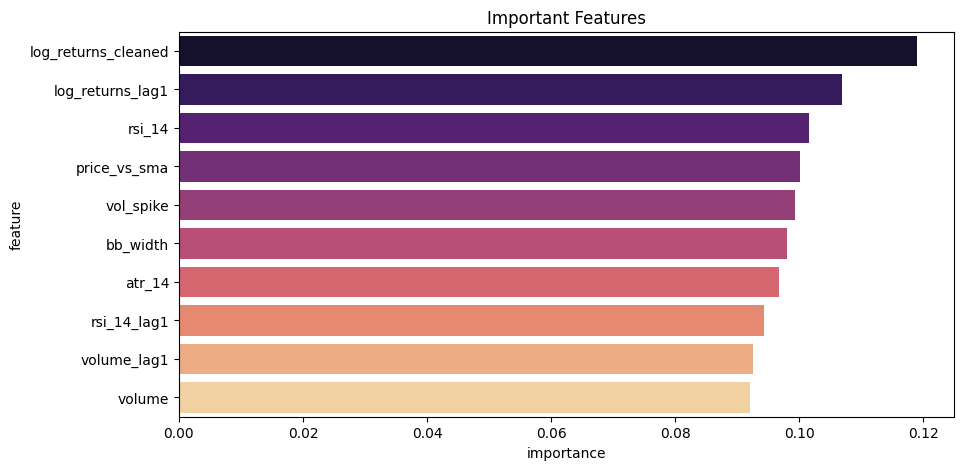

               feature  importance
3  log_returns_cleaned    0.118953
5     log_returns_lag1    0.106789
1               rsi_14    0.101482
7         price_vs_sma    0.100035
9            vol_spike    0.099367
8             bb_width    0.097945
2               atr_14    0.096672
4          rsi_14_lag1    0.094317
6          volume_lag1    0.092448
0               volume    0.091992


In [221]:
importances = model.feature_importances_
feature_names = features

feat_report = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_report = feat_report.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feat_report, palette='magma')
plt.title("Important Features")
plt.show()

print(feat_report)


In [222]:
conn.close()